<a href="https://colab.research.google.com/github/wajeeha-urooj/bioseq-cli/blob/main/notebooks/BioSeq-CLI-Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 BioSeq-CLI: Bioinformatics Sequence Analysis Toolkit

## Project Overview

BioSeq-CLI is a Python-based toolkit for inspecting and analyzing biological sequences stored in FASTA format.

Researchers may work with FASTA files containing a small number of sequences or thousands of sequences. Before performing downstream bioinformatics analysis, it is useful to understand the contents and basic quality of the sequence dataset.

This project develops a reusable workflow that can:

* Read biological sequences from FASTA files
* Perform basic sequence quality checks
* Calculate sequence statistics
* Analyze amino-acid composition
* Identify duplicate sequences
* Apply basic sequence filtering
* Generate a summary of the dataset

The workflow is designed to be reusable with different FASTA datasets rather than being limited to one organism or one research question.

## Why This Project?

FASTA files can come from public databases, laboratory experiments, sequencing projects, or other computational workflows. Even when the original biological data source is reliable, the downloaded or processed dataset should be inspected before it is used in further analysis.

The purpose of this toolkit is therefore not to verify the biological correctness of database records. Instead, it provides computational checks and summaries of the FASTA dataset being used by the researcher.

## Project Workflow

The overall workflow is:

**FASTA Input → Sequence Parsing → Quality Control → Sequence Statistics → Composition Analysis → Duplicate Detection → Filtering → Summary Report**

## Technologies

* Python
* Biopython
* pandas
* Jupyter/Google Colab
* Command-line interface development
* Git and GitHub

The final version of this project will be organized as a reusable command-line tool that can accept a researcher's own FASTA file.

# 1. Environment Setup

Before developing the sequence analysis toolkit, we first prepare the
Python environment and install the required libraries.

Biopython is the main biological computing library used in this project.
It provides tools for reading, manipulating, and analyzing biological
sequences and common bioinformatics file formats.

Pandas will be used later to organize sequence-analysis results into
structured tables.

The purpose of this step is to make sure that all required software
dependencies are available before we begin developing the toolkit.

In [ ]:
# Install the Python packages required for this project

!pip install biopython pandas

In [ ]:
# Import the libraries and check their installed versions

import Bio
import pandas as pd

print("Biopython version:", Bio.__version__)
print("Pandas version:", pd.__version__)
print("Environment ready!")

Biopython version: 1.88
Pandas version: 2.2.3
Environment ready!


# 2. FASTA Input

In this section, we provide the sequence dataset that will be analyzed by BioSeq-CLI.

The input is a FASTA file containing biological protein sequences. FASTA is a standard format used to store one or more biological sequences together with their sequence identifiers.

For this development stage, we use a real dataset of 60 reviewed human protein sequences obtained from UniProt.

## Why are we doing this?

Using a real biological dataset allows us to develop and test the toolkit using data similar to what researchers encounter in real bioinformatics workflows.

The toolkit is not restricted to 50 sequences or to human proteins. The same workflow should work with FASTA files containing different numbers and types of biological sequences.

## Input

The expected input is:

* A valid FASTA file
* One or more biological sequence records
* A sequence identifier for each record
* Protein sequences appropriate for the analysis

The file may be compressed as `.fasta.gz` or provided as an uncompressed `.fasta` file.

## Workflow

**FASTA file → Upload → Read sequences → Validate → Analyze**


In [ ]:
# Upload the FASTA file into the Colab environment

from google.colab import files

uploaded = files.upload()

if not uploaded:
    raise RuntimeError("No file was uploaded. Run this cell again and choose a FASTA file.")

# Colab renames a file to "name (1).ext" when the same name is uploaded again,
# so use the name Colab actually gives the file instead of typing it by hand
fasta_file = next(iter(uploaded))

print("File uploaded successfully:", fasta_file)

Saving uniprotkb_accession_A0A0C5B5G6_OR_access_2026_09_16.fasta.gz to uniprotkb_accession_A0A0C5B5G6_OR_access_2026_09_16.fasta (1).gz
File uploaded successfully.


# 3. Reading the FASTA Dataset


In this section, we read the FASTA file and convert each sequence record into a format that Python can work with.

The FASTA file contains biological sequence records. Each record includes a sequence identifier and its corresponding amino-acid sequence.

Files ending in .gz are opened with Python's gzip module and plain text files are opened normally. Biopython's SeqIO then parses the FASTA records.

## Why are we doing this?

Before performing sequence analysis, the toolkit needs to correctly read and recognize every sequence in the input file.

Using Biopython's `SeqIO` parser provides a standard and reliable way to work with FASTA files and makes the workflow reusable for other sequence datasets.

## Expected output

After reading the file, we will determine:

* How many sequence records were loaded
* The identifier of each sequence
* The length of each sequence
* A small preview of the sequences

The same approach can later be used with FASTA files containing different numbers of sequences and different biological organisms.

## Workflow

**Compressed FASTA → Open file → Parse records → Count sequences → Inspect records**


In [ ]:
from Bio import SeqIO
import gzip

# Gzip files start with two fixed bytes, so the file name does not matter
def is_gzip(path):
    with open(path, "rb") as file:
        return file.read(2) == b"\x1f\x8b"

opener = gzip.open if is_gzip(fasta_file) else open

with opener(fasta_file, "rt") as handle:
    records = list(SeqIO.parse(handle, "fasta"))

if not records:
    raise ValueError("No FASTA records were found. A FASTA file must start with '>'.")

print("Number of sequences:", len(records))

Number of sequences: 60


## 3.1 Inspecting the Sequence Records

We will inspect the first few sequence records loaded from the FASTA file.

Each FASTA record contains information such as:

* a sequence identifier
* the amino-acid sequence
* the sequence length

### Why are we doing this?

Before performing automated analysis, it is useful to confirm that the data were read correctly.

We do not need to print all sequences. Looking at a small number of records allows us to check the structure of the data without producing a very large output.

### Expected output

For each selected record, we will display:

* **ID:** the sequence identifier
* **Length:** the number of amino acids
* **Sequence preview:** the beginning of the amino-acid sequence

This type of inspection is useful when developing a reusable bioinformatics workflow because it helps identify problems with the input before further analysis.

In [ ]:
# Inspect the first 3 sequence records

for record in records[:3]:
    print("ID:", record.id)
    print("Length:", len(record.seq))
    print("Sequence:", record.seq[:50], "...")
    print("-" * 60)

ID: sp|A0A0C5B5G6|MOTSC_HUMAN
Length: 16
Sequence: MRWQEMGYIFYPRKLR ...
------------------------------------------------------------
ID: sp|A0A1B0GTW7|CIROP_HUMAN
Length: 788
Sequence: MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKSRSSS ...
------------------------------------------------------------
ID: sp|A0JNW5|BLT3B_HUMAN
Length: 1464
Sequence: MAGIIKKQILKHLSRFTKNLSPDKINLSTLKGEGELKNLELDEEVLQNML ...
------------------------------------------------------------


In [ ]:
from collections import Counter

def guess_molecule_type(records, share=0.9):
    """Say 'nucleotide' when at least 90% of the letters are A, C, G, T, U or N, otherwise 'protein'."""
    counts = Counter()
    for record in records:
        counts.update(str(record.seq).upper())

    letters = sum(n for character, n in counts.items() if character.isalpha())
    if letters == 0:
        return "protein"

    nucleotide_letters = sum(counts[c] for c in "ACGTUN")
    return "nucleotide" if nucleotide_letters / letters >= share else "protein"


molecule_type = guess_molecule_type(records)
print("Molecule type guessed from the letters:", molecule_type)

if molecule_type != "protein":
    print("WARNING: this toolkit is built for protein sequences, but this file looks like "
          "nucleotide sequences. The amino-acid checks below would not be meaningful.")

## 4. Sequence Quality Control

### 4.1 Checking for Empty Sequences

We will check whether any FASTA record contains an empty sequence.

An empty sequence means that a record has an identifier but contains no amino-acid residues.

### Why are we doing this?

An empty sequence cannot be used for most downstream sequence analyses.

Detecting such records early prevents them from causing problems later in the workflow.

### Expected output

The analysis will report:

* The number of empty sequences
* Their sequence identifiers, if any are found

For a clean dataset, we expect the number of empty sequences to be **0**.

This check is performed automatically so that the same workflow can be applied to other FASTA datasets.


In [ ]:
# Check for empty sequences

empty_sequences = [
    record.id
    for record in records
    if len(record.seq) == 0
]

print("Number of empty sequences:", len(empty_sequences))

if empty_sequences:
    print("Empty sequence IDs:")
    for seq_id in empty_sequences:
        print(seq_id)
else:
    print("No empty sequences found.")

Number of empty sequences: 0
No empty sequences found.


## 4.2 Checking for Unexpected Amino-Acid Characters

We will check the amino-acid sequences for characters that are not normally expected in a standard protein sequence.

The standard amino-acid alphabet contains 20 commonly occurring amino acids:

**A, C, D, E, F, G, H, I, K, L, M, N, P, Q, R, S, T, V, W, Y**

Some sequence datasets may also contain additional symbols such as **X**, which can represent an unknown or uncertain amino acid.

### Why are we doing this?

Unexpected characters can affect downstream sequence analysis.

For example, a sequence containing spaces, numbers, punctuation, or other symbols may indicate formatting or data-processing problems.

The purpose of this check is therefore to identify unusual characters so that the researcher can inspect them before continuing with analysis.

### Expected output

The program will report:

* Which characters occur outside the standard amino-acid alphabet
* Which sequence IDs contain those characters
* The total number of affected sequences

The check does **not automatically delete** these sequences. Instead, it reports the issue so the researcher can decide how to handle it.


In [ ]:
# Define the standard amino-acid alphabet

standard_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")

# Check every sequence for unexpected characters

invalid_sequences = {}

for record in records:
    sequence = str(record.seq).upper()
    unexpected = set(sequence) - standard_amino_acids

    if unexpected:
        invalid_sequences[record.id] = sorted(unexpected)

print("Number of sequences with unexpected characters:",
      len(invalid_sequences))

if invalid_sequences:
    print("\nSequences with unexpected characters:")

    for seq_id, characters in invalid_sequences.items():
        print(f"{seq_id}: {characters}")
else:
    print("No unexpected characters found.")

Number of sequences with unexpected characters: 0
No unexpected characters found.


## 4.3 Sequence Length Analysis

We will calculate the length of every protein sequence in the dataset.

Sequence length is simply the **number of amino acids** in a protein.

We will then summarize the lengths using:

* Minimum length
* Maximum length
* Mean length
* Median length

### Why are we doing this?

Protein sequences can have very different lengths. Examining their length distribution helps us understand the dataset and can reveal unusual records that may need further investigation.

For example, an unexpectedly short sequence may deserve inspection, while an unusually long sequence may represent a large protein or another type of biological record.

### Expected output

The analysis will provide a numerical summary of the sequence lengths.

These statistics will later become part of the automated summary produced by the BioSeq-CLI toolkit.


In [ ]:
import pandas as pd

# Calculate the length of every sequence

sequence_lengths = [len(record.seq) for record in records]

# Create a summary of sequence lengths

length_summary = pd.Series(sequence_lengths).describe()

print(length_summary)

count      60.000000
mean      582.150000
std       513.814971
min        16.000000
25%       229.500000
50%       393.000000
75%       804.500000
max      2624.000000
dtype: float64


## 4.4 Visualizing Sequence Length Distribution

We will visualize the distribution of protein sequence lengths using a histogram.

A histogram groups sequence lengths into ranges and shows how many proteins fall within each range.

### Why are we doing this?

Summary statistics tell us the numerical values, but a visualization helps us see the overall pattern of the dataset.

It can reveal whether most proteins have similar lengths or whether the dataset contains a mixture of short, medium, and very long proteins.

### Expected output

The histogram will show:

* Sequence length on the x-axis
* Number of protein sequences on the y-axis

This visualization will help identify the overall distribution and potential unusually short or long sequences.


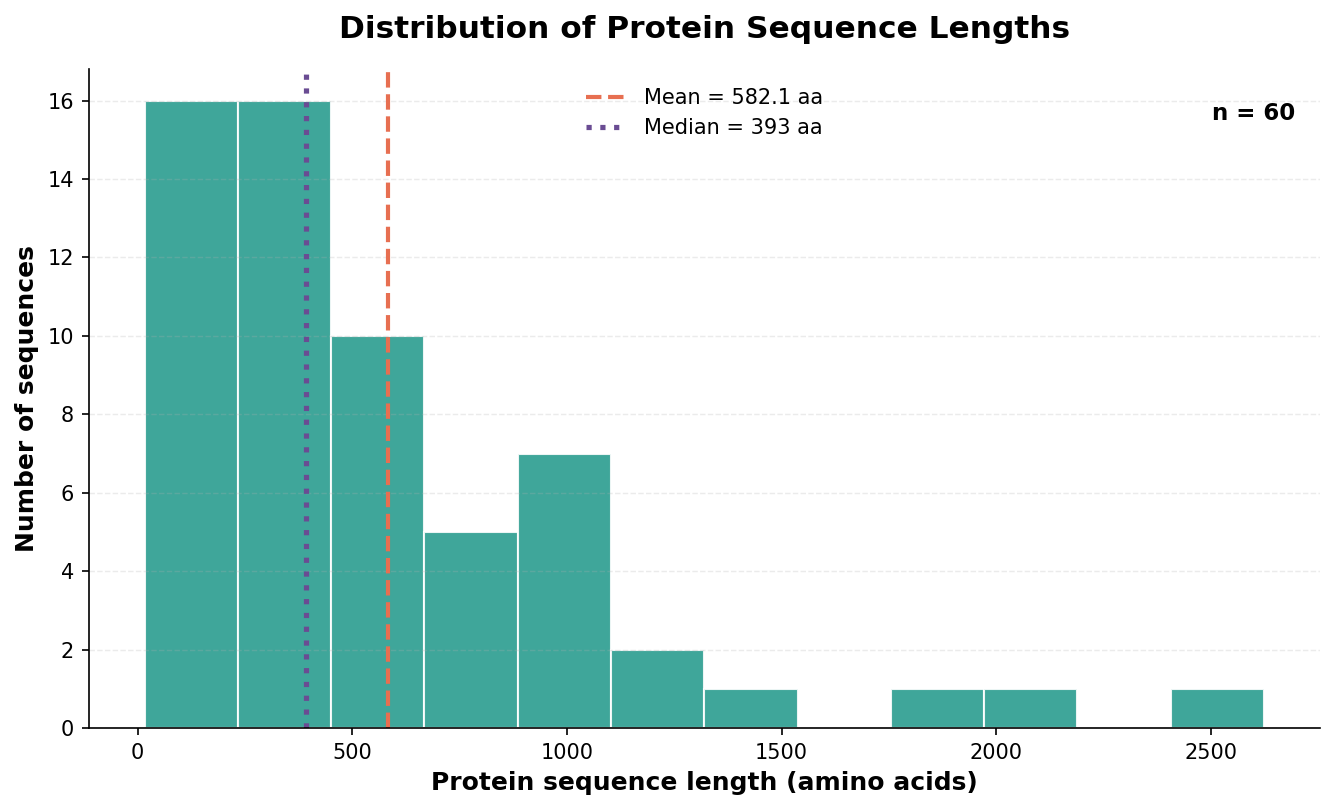

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate summary statistics
mean_length = np.mean(sequence_lengths)
median_length = np.median(sequence_lengths)

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

# Histogram
ax.hist(
    sequence_lengths,
    bins=12,
    color="#2A9D8F",
    edgecolor="white",
    linewidth=1.0,
    alpha=0.9
)

# Mean line
ax.axvline(
    mean_length,
    color="#E76F51",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean_length:.1f} aa"
)

# Median line
ax.axvline(
    median_length,
    color="#6A4C93",
    linestyle=":",
    linewidth=2.5,
    label=f"Median = {median_length:.0f} aa"
)

# Labels
ax.set_xlabel(
    "Protein sequence length (amino acids)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Number of sequences",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Distribution of Protein Sequence Lengths",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Dataset size
ax.text(
    0.98,
    0.95,
    f"n = {len(sequence_lengths)}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick formatting
ax.tick_params(axis="both", labelsize=10)

# Legend
ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper center"
)

plt.tight_layout()

# Save publication-quality figure
plt.savefig(
    "protein_sequence_length_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4.5 Inspecting the Shortest and Longest Sequences

Now we will identify the shortest and longest protein sequences in the dataset.

### Why are we doing this?

Sequence length alone does not determine whether a protein record is correct or incorrect. Very short sequences may represent small proteins or peptides, while very long sequences may represent large or multidomain proteins.

Therefore, instead of automatically removing these records, we will inspect the extreme sequence lengths and identify the corresponding sequence records.

In [ ]:
length_data = pd.DataFrame({
    "ID": [record.id for record in records],
    "Length": [len(record.seq) for record in records]
}).sort_values("Length")

print("Shortest 5 sequences:")
display(length_data.head())

print("Longest 5 sequences:")
display(
    length_data
    .tail()
    .sort_values("Length", ascending=False)
)

Shortest 5 sequences:


,ID,Length
0,sp|A0A0C5B5G6|MOTSC_HUMAN,16
43,sp|E0CX11|STMP1_HUMAN,47
7,sp|A1L190|SYCE3_HUMAN,88
49,sp|O00168|PLM_HUMAN,92
40,sp|C9JLW8|MCRI1_HUMAN,97


Longest 5 sequences:


,ID,Length
19,sp|A6H8Y1|BDP1_HUMAN,2624
25,sp|A6NKB5|PCX2_HUMAN,2137
28,sp|A7E2V4|ZSWM8_HUMAN,1837
2,sp|A0JNW5|BLT3B_HUMAN,1464
23,sp|A6NGG8|PCARE_HUMAN,1288


## 4.6 Checking for Duplicate Sequences

We will check whether the FASTA dataset contains identical protein sequences.

Two or more records are considered duplicates when their complete amino-acid sequences are exactly the same, even if their sequence identifiers are different.

Duplicate sequences can occur in biological datasets for several reasons, such as:

* Multiple records representing the same sequence
* Different identifiers associated with an identical protein sequence
* Merging sequences from multiple sources
* Redundant datasets created for computational analysis

Detecting duplicates is useful because repeated sequences may unintentionally give some proteins greater representation in downstream analyses.


In [ ]:
from collections import defaultdict

sequence_groups = defaultdict(list)

for record in records:
    sequence = str(record.seq).upper()
    sequence_groups[sequence].append(record.id)

duplicate_groups = {
    sequence: ids
    for sequence, ids in sequence_groups.items()
    if len(ids) > 1
}

print("Total sequences:", len(records))
print("Unique sequences:", len(sequence_groups))
print("Duplicate sequence groups:", len(duplicate_groups))

Total sequences: 60
Unique sequences: 60
Duplicate sequence groups: 0


In [ ]:
if duplicate_groups:
    print("\nDuplicate sequences found:\n")

    for i, (sequence, ids) in enumerate(duplicate_groups.items(), start=1):
        print(f"Duplicate group {i}")
        print("Sequence IDs:", ids)
        print("Sequence length:", len(sequence))
        print("-" * 60)
else:
    print("No duplicate sequences found.")

No duplicate sequences found.


In [ ]:
import io
from collections import Counter

standard_amino_acids = set("ACDEFGHIKLMNPQRSTVWY")


def run_quality_checks(records):
    """Run the basic quality checks on a list of records and return the results."""
    empty = [r.id for r in records if len(r.seq) == 0]

    unexpected = {}
    for r in records:
        found = set(str(r.seq).upper()) - standard_amino_acids
        if found:
            unexpected[r.id] = sorted(found)

    repeated_ids = {i: n for i, n in Counter(r.id for r in records).items() if n > 1}

    groups = {}
    for r in records:
        sequence = str(r.seq).upper()
        if sequence:
            groups.setdefault(sequence, []).append(r.id)
    duplicate_groups = [ids for ids in groups.values() if len(ids) > 1]

    return {"empty": empty, "unexpected": unexpected,
            "repeated_ids": repeated_ids, "duplicate_groups": duplicate_groups}


# A small file with one problem of each kind
bad_fasta = """>ok_1
MKTAYIAKQRQISFVKSHFSRQLEERLG
>has_x
MKTAYIAKXXQRQISFVK
>has_star_and_gap
MKTAYIAK*QRQ-ISF
>empty_one
>copy_of_ok_1
MKTAYIAKQRQISFVKSHFSRQLEERLG
>ok_1
GSHMLEDPVDAFKQLLERAGQ
"""

test_records = list(SeqIO.parse(io.StringIO(bad_fasta), "fasta"))
test_results = run_quality_checks(test_records)

for name, value in test_results.items():
    print(name, "->", value)

# If one of these lines fails, a check is not working
assert test_results["empty"] == ["empty_one"]
assert set(test_results["unexpected"]) == {"has_x", "has_star_and_gap"}
assert test_results["unexpected"]["has_star_and_gap"] == ["*", "-"]
assert test_results["repeated_ids"] == {"ok_1": 2}
assert test_results["duplicate_groups"] == [["ok_1", "copy_of_ok_1"]]
print("\nAll checks found exactly the problems that were put in the test file.")

# The same checks on the real dataset
print("\nResults for the real dataset:")
for name, value in run_quality_checks(records).items():
    print(name, "->", value)

## 5. Amino-Acid Composition Analysis

We will calculate the frequency of each standard amino acid across all protein sequences in the dataset.

The analysis will count how many times each amino acid occurs and calculate its percentage of the total amino-acid residues.

Amino-acid composition provides a simple summary of the biochemical characteristics of a protein dataset.

Different proteins can have different amino-acid compositions depending on their structure, function, cellular environment, and evolutionary history.

Calculating composition across the dataset allows us to summarize these patterns quantitatively and provides features that can also be used in downstream computational analyses.



In [ ]:
from collections import Counter

# Count amino acids across all sequences
amino_acid_counts = Counter()

for record in records:
    amino_acid_counts.update(str(record.seq).upper())

# The 20 standard amino acids, in alphabetical order
AA_ORDER = "ACDEFGHIKLMNPQRSTVWY"

total_residues = sum(amino_acid_counts[aa] for aa in AA_ORDER)

if total_residues == 0:
    raise ValueError("There are no standard amino acids in this file, so composition cannot be calculated.")

# Letters such as X or U are not part of the percentages, so say how many there are
print("Letters not counted (X, U, *, and so on):",
      sum(amino_acid_counts.values()) - total_residues)

composition_data = []

for aa in AA_ORDER:
    count = amino_acid_counts[aa]
    composition_data.append({
        "Amino Acid": aa,
        "Count": count,
        "Percentage": (count / total_residues) * 100
    })

composition_df = pd.DataFrame(composition_data)

composition_df

,Amino Acid,Count,Percentage
0,A,2460,7.042858
1,C,889,2.545163
2,D,1586,4.540640
3,E,2623,7.509519
4,F,1209,3.461307
5,G,2204,6.309943
6,H,940,2.691174
7,I,1424,4.076842
8,K,2009,5.751668
9,L,3460,9.905809



## 5.1 Visualizing Amino-Acid Composition

We will visualize the percentage composition of the 20 standard amino acids across all protein sequences in the dataset.

The numerical table provides exact amino-acid frequencies, while the graph makes differences between amino acids easier to compare.

This visualization provides a concise overview of the overall amino-acid composition of the protein dataset.


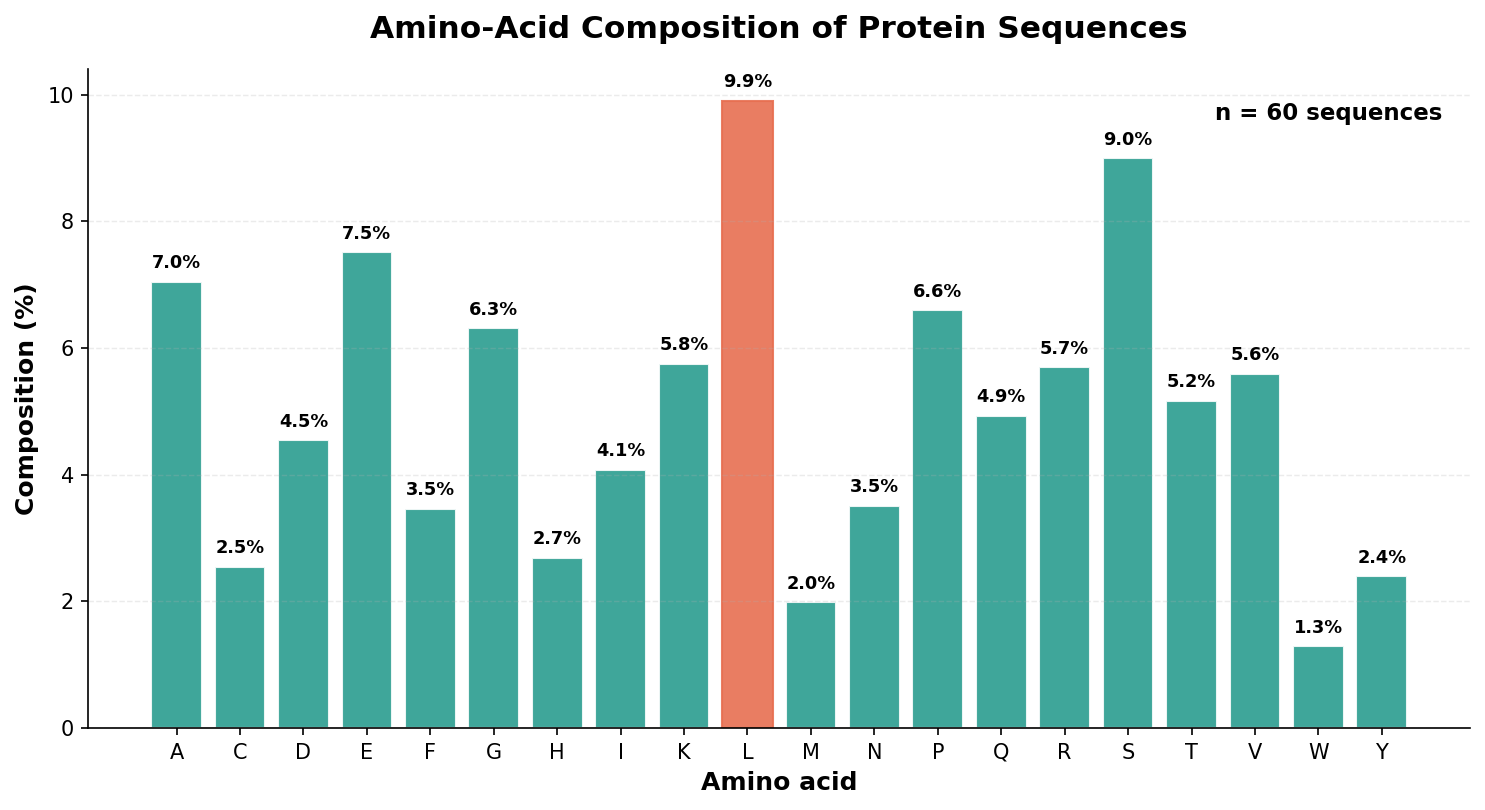

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract amino-acid composition
amino_acids = composition_df["Amino Acid"]
percentages = composition_df["Percentage"]

# Identify most abundant amino acid
max_index = percentages.idxmax()
max_aa = amino_acids[max_index]
max_percentage = percentages[max_index]

# Create figure
fig, ax = plt.subplots(figsize=(10, 5.5), dpi=150)

# Bar chart
bars = ax.bar(
    amino_acids,
    percentages,
    color="#2A9D8F",
    edgecolor="white",
    linewidth=1.0,
    alpha=0.9
)

# Highlight most abundant amino acid
bars[max_index].set_color("#E76F51")

# Add percentage labels
for bar, value in zip(bars, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8.5,
        fontweight="bold"
    )

# Labels
ax.set_xlabel(
    "Amino acid",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Composition (%)",
    fontsize=12,
    fontweight="bold"
)

# Title
ax.set_title(
    "Amino-Acid Composition of Protein Sequences",
    fontsize=15,
    fontweight="bold",
    pad=15
)

# Dataset information
ax.text(
    0.98,
    0.95,
    f"n = {len(records)} sequences",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Tick formatting
ax.tick_params(
    axis="both",
    labelsize=10
)

# Keep labels readable
plt.xticks(rotation=0)

plt.tight_layout()

# Save publication-quality figure
plt.savefig(
    "amino_acid_composition.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 5.2 Ranking Amino-Acid Abundance

We will rank the 20 standard amino acids according to their percentage composition in the protein dataset.

The most abundant and least abundant amino acids will be identified automatically from the calculated composition table.



Ranking allows us to summarize the composition results without relying only on visual inspection of the graph.

This also makes the workflow reusable because the ranking will automatically change when a different FASTA dataset is analyzed.


In [ ]:
# Rank amino acids by percentage composition
ranked_composition = composition_df.sort_values(
    "Percentage",
    ascending=False
).reset_index(drop=True)

print("Top 5 most abundant amino acids:")
display(
    ranked_composition.head(5)
)

print("Top 5 least abundant amino acids:")
display(
    ranked_composition.tail(5).sort_values(
        "Percentage",
        ascending=True
    )
)

Top 5 most abundant amino acids:


,Amino Acid,Count,Percentage
0,L,3460,9.905809
1,S,3143,8.998254
2,E,2623,7.509519
3,A,2460,7.042858
4,P,2303,6.593375


Top 5 least abundant amino acids:


,Amino Acid,Count,Percentage
19,W,450,1.288328
18,M,693,1.984025
17,Y,838,2.399153
16,C,889,2.545163
15,H,940,2.691174


In [ ]:
most_abundant = ranked_composition.iloc[0]
least_abundant = ranked_composition.iloc[-1]

print(
    f"Most abundant amino acid: "
    f"{most_abundant['Amino Acid']} "
    f"({most_abundant['Percentage']:.2f}%)"
)

print(
    f"Least abundant amino acid: "
    f"{least_abundant['Amino Acid']} "
    f"({least_abundant['Percentage']:.2f}%)"
)

Most abundant amino acid: L (9.91%)
Least abundant amino acid: W (1.29%)


## 6. Sequence Filtering

### What are we doing?

We will implement an optional sequence-length filtering step.

The user can define a minimum and maximum sequence length, and the toolkit will identify sequences that fall within the selected range.

### Why are we doing this?

Different bioinformatics analyses may require different sequence-length criteria.

For example, a researcher working with a specific protein family may want to exclude very short fragments or very long proteins.

Because appropriate thresholds depend on the research question, the toolkit will allow the user to define the criteria rather than applying a fixed biological threshold.

### Expected output

The analysis will report:

* The selected minimum length
* The selected maximum length
* Number of sequences retained
* Number of sequences excluded

The original dataset will not be modified.


In [ ]:
# User-defined filtering thresholds
min_length = 50
max_length = 2000

filtered_records = [
    record
    for record in records
    if min_length <= len(record.seq) <= max_length
]

print("Original sequences:", len(records))
print("Filtered sequences:", len(filtered_records))
print("Excluded sequences:", len(records) - len(filtered_records))
print(f"Length range: {min_length}–{max_length} aa")

Original sequences: 60
Filtered sequences: 56
Excluded sequences: 4
Length range: 50–2000 aa


In [ ]:
# Save the sequences that passed the filter as a new FASTA file
SeqIO.write(filtered_records, "filtered_sequences.fasta", "fasta")
print("Saved", len(filtered_records), "sequences to filtered_sequences.fasta")

# Keep a record of what was removed and why
removed = []
for record in records:
    length = len(record.seq)
    if length < min_length:
        removed.append({"ID": record.id, "Length": length, "Reason": f"shorter than {min_length}"})
    elif length > max_length:
        removed.append({"ID": record.id, "Length": length, "Reason": f"longer than {max_length}"})

removed_df = pd.DataFrame(removed, columns=["ID", "Length", "Reason"])
removed_df.to_csv("removed_sequences.csv", index=False)

print("Removed sequences:", len(removed_df))
display(removed_df)

## 7. Sequence Summary Table

### What are we doing?

We will create a structured table containing basic information about every protein sequence.

### Why are we doing this?

A structured table makes sequence-level information easier to inspect, analyze, filter, and export.

This table will also provide a foundation for generating automated reports.


In [ ]:
summary_data = []

for record in records:
    sequence = str(record.seq).upper()
    unexpected = set(sequence) - set(standard_amino_acids)

    summary_data.append({
        "ID": record.id,
        "Length": len(sequence),
        "Unexpected_Characters": ",".join(sorted(unexpected))
        if unexpected else "None"
    })

sequence_summary_df = pd.DataFrame(summary_data)

display(sequence_summary_df.head(10))

,ID,Length,Unexpected_Characters
0,sp|A0A0C5B5G6|MOTSC_HUMAN,16,None
1,sp|A0A1B0GTW7|CIROP_HUMAN,788,None
2,sp|A0JNW5|BLT3B_HUMAN,1464,None
3,sp|A0JP26|POTB3_HUMAN,581,None
4,sp|A0PK11|CLRN2_HUMAN,232,None
5,sp|A1A4S6|RHG10_HUMAN,786,None
6,sp|A1A519|F170A_HUMAN,330,None
7,sp|A1L190|SYCE3_HUMAN,88,None
8,sp|A1L3X0|ELOV7_HUMAN,281,None
9,sp|A1X283|SPD2B_HUMAN,911,None


## 10. Sequence Diversity Using Shannon Entropy

We will calculate Shannon entropy for each protein sequence.

Shannon entropy is a measure of sequence composition diversity based on the frequency of amino acids within a sequence.

### Why are we doing this?

Two protein sequences can have the same length but very different amino-acid compositions.

Entropy provides an additional numerical feature describing the diversity of residues within each sequence.

Higher entropy generally indicates a more diverse amino-acid composition, while lower entropy indicates that fewer amino-acid types dominate the sequence.

In [ ]:
from collections import Counter
import math

def sequence_entropy(sequence):
    counts = Counter(sequence)
    length = len(sequence)

    entropy = 0

    for count in counts.values():
        probability = count / length
        entropy -= probability * math.log2(probability)

    return entropy


sequence_summary_df["Shannon_Entropy"] = [
    sequence_entropy(str(record.seq).upper())
    for record in records
]

display(
    sequence_summary_df[
        ["ID", "Length", "Shannon_Entropy"]
    ].head(10)
)

,ID,Length,Shannon_Entropy
0,sp|A0A0C5B5G6|MOTSC_HUMAN,16,3.452820
1,sp|A0A1B0GTW7|CIROP_HUMAN,788,4.064488
2,sp|A0JNW5|BLT3B_HUMAN,1464,4.131155
3,sp|A0JP26|POTB3_HUMAN,581,4.121349
4,sp|A0PK11|CLRN2_HUMAN,232,4.031608
5,sp|A1A4S6|RHG10_HUMAN,786,4.156936
6,sp|A1A519|F170A_HUMAN,330,4.022465
7,sp|A1L190|SYCE3_HUMAN,88,3.861942
8,sp|A1L3X0|ELOV7_HUMAN,281,4.168963
9,sp|A1X283|SPD2B_HUMAN,911,4.063594


## 11. Ranking Sequence Diversity

### What are we doing?

We will rank protein sequences according to their Shannon entropy.

### Why are we doing this?

Ranking allows us to identify sequences with relatively high and low amino-acid diversity.

This provides another way of exploring sequence characteristics beyond sequence length alone.


In [ ]:
# The entropy of a whole sequence depends on its length when the sequence is short,
# so only sequences of at least 100 amino acids are ranked
MIN_LENGTH_FOR_ENTROPY_RANKING = 100

rankable = sequence_summary_df[sequence_summary_df["Length"] >= MIN_LENGTH_FOR_ENTROPY_RANKING]

print(f"Sequences ranked: {len(rankable)} of {len(sequence_summary_df)} "
      f"(length of at least {MIN_LENGTH_FOR_ENTROPY_RANKING})")

diversity_ranking = rankable.sort_values("Shannon_Entropy", ascending=False)

print("Highest entropy:")
display(diversity_ranking.head(5))

print("Lowest entropy:")
display(diversity_ranking.tail(5).sort_values("Shannon_Entropy"))

In [ ]:
import math
from collections import Counter
from functools import lru_cache

WINDOW = 12        # residues per window
THRESHOLD = 1.8    # bits: a window at or below this entropy counts as low complexity


@lru_cache(maxsize=None)
def window_entropy(sorted_counts):
    # The entropy only depends on the letter counts, so results can be reused
    total = sum(sorted_counts)
    return max(0.0, -sum((n / total) * math.log2(n / total) for n in sorted_counts))


def low_complexity_fraction(sequence, window=WINDOW, threshold=THRESHOLD):
    """Share of residues that lie inside at least one low-entropy window."""
    length = len(sequence)
    if length < window:
        return 0.0

    counts = Counter(sequence[:window])
    covered = 0
    covered_until = 0

    for start in range(length - window + 1):
        if start:
            leaving = sequence[start - 1]
            counts[leaving] -= 1
            if counts[leaving] == 0:
                del counts[leaving]
            counts[sequence[start + window - 1]] += 1

        if window_entropy(tuple(sorted(counts.values()))) <= threshold:
            end = start + window
            covered += end - max(start, covered_until)
            covered_until = end

    return covered / length


# Quick tests: a run of one amino acid is fully low complexity, a varied sequence is not
assert low_complexity_fraction("Q" * 30) == 1.0
assert low_complexity_fraction("ACDEFGHIKLMNPQRSTVWY" * 2) == 0.0

sequence_summary_df["Low_Complexity_Fraction"] = [
    low_complexity_fraction(str(record.seq).upper()) for record in records
]

flagged = sequence_summary_df[sequence_summary_df["Low_Complexity_Fraction"] > 0]
print("Sequences with at least one low-complexity window:", len(flagged), "of", len(records))

display(
    flagged[["ID", "Length", "Low_Complexity_Fraction"]]
    .sort_values("Low_Complexity_Fraction", ascending=False)
    .head(5)
)

## 12. Sequence Length and Diversity Visualization

### What are we doing?

We will visualize the relationship between protein sequence length and amino-acid diversity.

### Why are we doing this?

Examining two sequence-level features together can reveal whether for short sequences a rise in entropy with length is expected from the method itself, so this plot is only descriptive.

This visualization is exploratory and is not intended to establish a biological causal relationship.


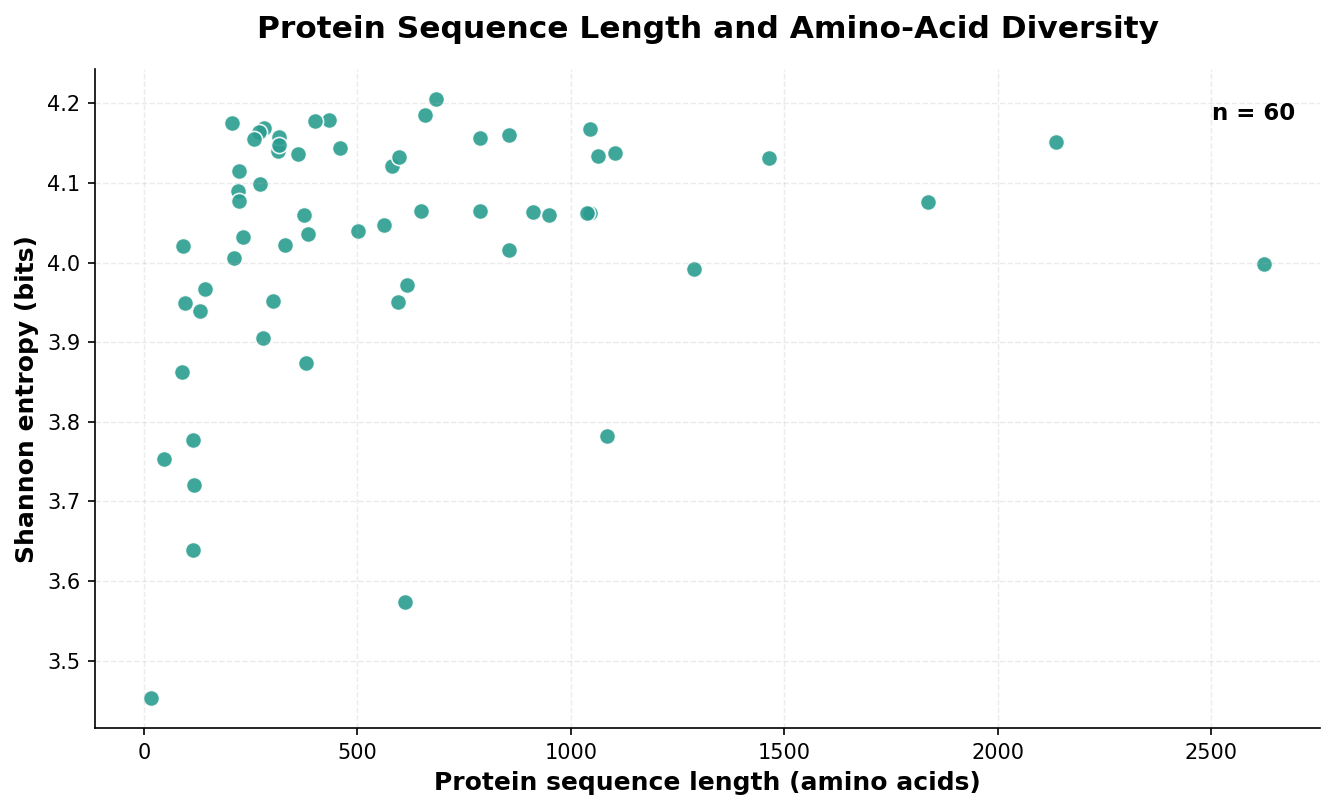

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)

ax.scatter(
    sequence_summary_df["Length"],
    sequence_summary_df["Shannon_Entropy"],
    color="#2A9D8F",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.9,
    s=60
)

ax.set_xlabel(
    "Protein sequence length (amino acids)",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Shannon entropy (bits)",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Protein Sequence Length and Amino-Acid Diversity",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.text(
    0.98,
    0.95,
    f"n = {len(records)}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    fontweight="bold"
)

ax.grid(
    axis="both",
    linestyle="--",
    linewidth=0.7,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", labelsize=10)

plt.tight_layout()

plt.savefig(
    "sequence_length_vs_entropy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 13. Automated Dataset Report

### What are we doing?

We will combine the main sequence-analysis results into a single automated report.

### Why are we doing this?

A researcher should not have to manually collect results from multiple notebook cells.

The toolkit should summarize the dataset automatically after analysis.

### Report contents

The report will include:

* Number of sequences
* Number of unique sequences
* Duplicate sequence groups
* Empty sequences
* Sequences containing unexpected characters
* Minimum sequence length
* Maximum sequence length
* Mean sequence length
* Median sequence length
* Amino-acid composition


In [ ]:
from collections import Counter

report = {
    "Total sequences": len(records),
    "Molecule type (guessed)": molecule_type,
    "Unique sequences": len(sequence_groups),
    "Duplicate sequence groups": len(duplicate_groups),
    "IDs used more than once": sum(1 for n in Counter(r.id for r in records).values() if n > 1),
    "Empty sequences": len(empty_sequences),
    "Sequences with unexpected characters": len(invalid_sequences),
    "Minimum length": int(np.min(sequence_lengths)),
    "Maximum length": int(np.max(sequence_lengths)),
    "Mean length": round(float(np.mean(sequence_lengths)), 2),
    "Median length": round(float(np.median(sequence_lengths)), 2)
}

for key, value in report.items():
    print(f"{key}: {value}")

Total sequences: 60
Unique sequences: 60
Duplicate sequence groups: 0
Empty sequences: 0
Sequences with unexpected characters: 0
Minimum length: 16
Maximum length: 2624
Mean length: 582.15
Median length: 393.0


## 14. Exporting Analysis Results

### What are we doing?

We will export the sequence-level summary and amino-acid composition results as CSV files.

### Why are we doing this?

CSV files are widely supported by statistical, visualization, and bioinformatics software.

Exporting results allows researchers to use the output in downstream analyses without rerunning the complete workflow.

### Output files

The toolkit will generate:

* `sequence_summary.csv`
* `amino_acid_composition.csv`


In [ ]:
sequence_summary_df.to_csv(
    "sequence_summary.csv",
    index=False
)

composition_df.to_csv(
    "amino_acid_composition.csv",
    index=False
)

print("Results exported successfully.")

Results exported successfully.


In [ ]:
with open("bioseq_report.txt", "w") as file:

    file.write("BioSeq-CLI Sequence Analysis Report\n")
    file.write("=" * 45 + "\n\n")

    for key, value in report.items():
        file.write(f"{key}: {value}\n")

    file.write("\nAmino-Acid Composition\n")
    file.write("-" * 45 + "\n")

    for _, row in composition_df.iterrows():
        file.write(
            f"{row['Amino Acid']}: "
            f"{row['Percentage']:.2f}%\n"
        )

print("Text report created successfully.")

Text report created successfully.


In [ ]:
filtered_lengths = [
    len(record.seq)
    for record in filtered_records
]

print("Filtered dataset summary")
print("-" * 30)

print("Sequences:", len(filtered_records))

if filtered_lengths:
    print("Minimum length:", min(filtered_lengths))
    print("Maximum length:", max(filtered_lengths))
    print("Mean length:", round(np.mean(filtered_lengths), 2))
else:
    print("No sequences passed the selected criteria.")

Filtered dataset summary
------------------------------
Sequences: 56
Minimum length: 88
Maximum length: 1837
Mean length: 537.59


# 17. Summary

In this notebook, we developed and tested a reusable workflow for protein FASTA sequence analysis.

The workflow included:

1. FASTA input and parsing
2. Sequence record inspection
3. Empty-sequence detection
4. Unexpected-character detection
5. Sequence-length analysis
6. Sequence-length visualization
7. Duplicate-sequence detection
8. Amino-acid composition analysis
9. Amino-acid frequency ranking
10. Sequence-length filtering
11. Shannon entropy calculation
12. Sequence diversity analysis
13. Automated dataset summarization
14. Export of sequence-level results
15. Generation of a text-based analysis report

The workflow was developed using a real protein FASTA dataset and was designed so that the same analysis can be applied to other FASTA datasets.
